## Project Title: Online Retail Data Analysis (EDA)

Online Retail Dataset – Data Cleaning & Exploratory Data Analysis (EDA)

Objective
To clean, structure, and analyze e-commerce transactional data in order to uncover sales trends, customer behavior, and generate meaningful business insights.

1. IMPORTING LIBRARIES

In this step, we import the essential Python libraries required for data analysis and visualization.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. DATA INGESTION

In this step, we load the dataset into our working environment using the Pandas library. The dataset is read from a CSV file and stored in a DataFrame called df, which allows us to easily manipulate and analyze the data.

The encoding='latin1' parameter is used to correctly read special characters in the dataset that may not be properly handled using the default encoding.

In [3]:
# Load dataset
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

# Preview dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


3. DATASET STRUCTURE OVERVIEW

In this step, we explore the structure of the dataset to understand its size and data types. This helps us gain a quick overview before performing any data cleaning or analysis.

df.shape returns the number of rows and columns in the dataset.
df.info() provides a summary of the dataset, including column names, non-null values, data types, and memory usage.

This step is important for identifying missing values and understanding the overall composition of the data.

In [4]:
# Dataset structure
print("Shape:", df.shape)
df.info()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


4. DATA FAMILIARIAZATION

This stage involves understanding the structure and basic characteristics of the dataset using methods such as shape, info(), describe(), and checking for missing values and data types.

The dataset contains both numerical variables (e.g., Quantity, UnitPrice) and categorical variables (e.g., Country, Description, CustomerID).

In [5]:
# Understanding the size of the dataset
df.shape

(541909, 8)

In [6]:
# Check for missing values
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [36]:
# Number of unique values in each column of the dataset
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [7]:
# Statistical summary of the numerical columns in the raw dataset
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Interpretation

The dataset consists of 541,909 records and 8 variables, indicating a large transactional dataset suitable for detailed analysis. It includes key fields such as Quantity, UnitPrice, CustomerID, and InvoiceDate, which are essential for understanding sales behavior, customer activity, and revenue patterns.

From the summary statistics, CustomerID appears as a numerical variable because its data type in the raw dataset is numeric (float). However, during the data cleaning stage, it will be converted to a string (object) data type since it represents a customer identifier rather than a value for numerical computation.

Overall, the dataset contains a mix of numerical variables (e.g., Quantity and UnitPrice) and categorical variables (e.g., Country and Description), making it suitable for statistical analysis, visualization, and exploratory data analysis (EDA).

5. DATA CLEANING

5.1 Missing Values

Missing values in CustomerID and Description were removed because these fields are essential for customer-level and product-level analysis. Removing them helps ensure the accuracy and reliability of insights derived from the dataset.

In [8]:
# Remove rows with missing values in CustomerID and Description columns
df = df.dropna(subset=['CustomerID', 'Description'])

5.2 Duplicates

Duplicate records were identified and removed to ensure data integrity and prevent distortion in transactional analysis.

In [9]:
# Data Cleaning: Handling Duplicates

# Check for duplicate rows in the dataset
print(df.duplicated().sum())

# Remove duplicate rows to ensure data integrity
df = df.drop_duplicates()

5225


5.3 Data Type Conversion and Standardization

This section documents changes made to variable data types to ensure proper analysis and interpretation.

The CustomerID column was cleaned and converted from a numeric format with decimal values (e.g., 17850.0) into a string (object) to ensure it is treated strictly as an identifier and not used for numerical calculations.

The InvoiceDate column was converted to datetime format to support time-series analysis and enable temporal operations such as grouping by day, month, or year.

These conversions improve data consistency, accuracy, and ensure variables are in appropriate formats for effective analysis.

In [10]:
# Convert InvoiceDate to datetime format for time-series analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Clean CustomerID (remove .0) and convert to string identifier
df['CustomerID'] = (
    df['CustomerID']
    .astype(str)
    .str.replace('.0', '', regex=False)
)

5.4 Data Validation and Business Rule Filtering

This step involves identifying and removing problematic records such as returned or cancelled transactions, as well as invalid sales values. To ensure data quality and accuracy, negative quantities, zero values, and cancelled transactions were removed so that only valid sales records were retained for analysis.

In [11]:
# Data Validation (Business Rules)

# Remove cancelled transactions
# Invoices beginning with "C" indicate cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantities (keep only positive sales quantities)
df = df[df['Quantity'] > 0]

# Remove invalid unit prices (keep only positive values)
df = df[df['UnitPrice'] > 0]

5.5 Feature Engineering

This stage involves creating new variables from existing data to enhance analysis and generate deeper insights. A Revenue column was created to measure total sales per transaction by multiplying quantity and unit price. Additionally, time-based features such as Year and Month were extracted from the InvoiceDate column to support temporal analysis of sales trends.

In [12]:
# Create Revenue column (total sales per transaction)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract Year from InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year

# Extract Month (Year-Month format) for trend analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')

5.6 Preview of Cleaned Dataset

After completing data cleaning and transformation steps, the dataset was previewed to confirm that all changes were successfully applied. This helps ensure that missing values, duplicates, data types, and newly created features are correctly reflected before proceeding to exploratory data analysis (EDA) and visualization.

In [13]:
# Preview the cleaned dataset after all data cleaning and feature engineering steps
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12


In [14]:
# Identify numerical and categorical features for EDA and visualization

# Select numerical columns (used for statistical analysis)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Select categorical columns (used for grouping and categorical analysis)
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Display numerical columns
print("Numerical Columns:")
print(numerical_cols)

# Display categorical columns
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Quantity', 'UnitPrice', 'Revenue'], dtype='str')

Categorical Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Country'], dtype='str')


In [30]:
# Display the shape of the cleaned dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Check for any remaining missing values after data cleaning
print("\nMissing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (392692, 11)

Missing Values per Column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
dtype: int64


In [15]:
# Summary statistics for the cleaned dataset (numerical features only)
# Provides count, mean, std, min, max, and quartile values for data understanding

df.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue,Year
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,22.631500,2010.934631
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000,2010.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.950000,2011.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,12.450000,2011.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,19.800000,2011.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000,2011.000000
std,180.492832,NaN,22.241836,311.099224,0.247177


6. EXPLORATORY DATA ANALYSIS (EDA)
   
6.1 Top Selling Products

This analysis identifies the top 10 best-selling products based on total quantity sold. It helps to understand customer demand patterns and highlights the most popular items in the dataset. This insight is useful for inventory planning, sales strategy, and product performance evaluation.

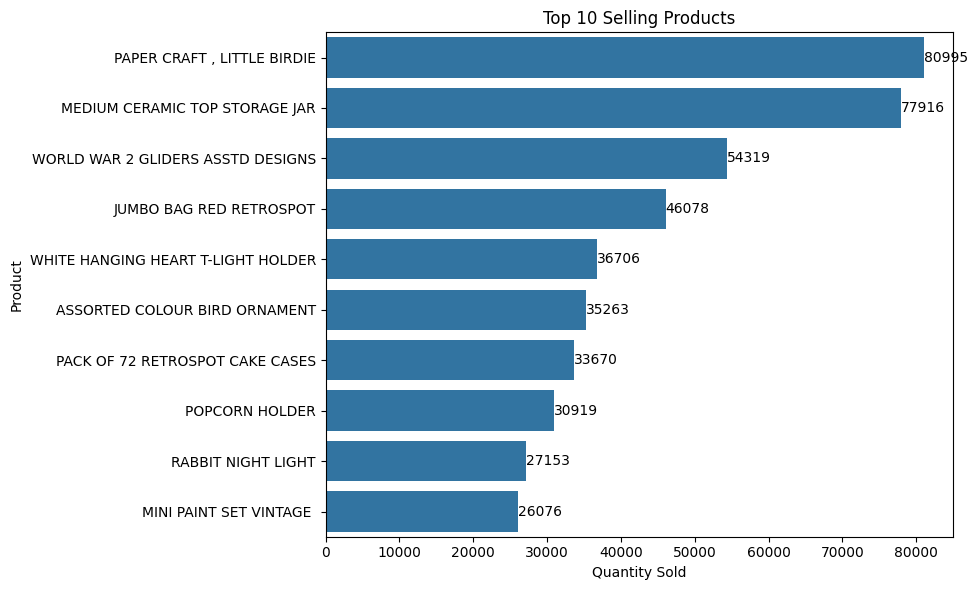

In [16]:
# Top Selling Products Analysis

# Group data by product description and sum quantities sold
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

# Add values inside bars
ax.bar_label(ax.containers[0], fmt="%.0f")

# Fix layout issues (IMPORTANT)
plt.tight_layout()
plt.subplots_adjust(left=0.35)

plt.show()

Interpretation / Insight

A small number of products account for the highest proportion of total sales volume, indicating strong demand concentration.
Sales performance is not evenly distributed, as a few high-performing items significantly outperform others in quantity sold.
These top-selling products can be prioritized for inventory management, restocking, and marketing focus to maximize revenue and reduce stockouts.

6.2 Revenue by Country

This analysis shows the distribution of total revenue across different countries to identify the highest-performing markets.

The visualization highlights the top 10 countries contributing to overall sales revenue.

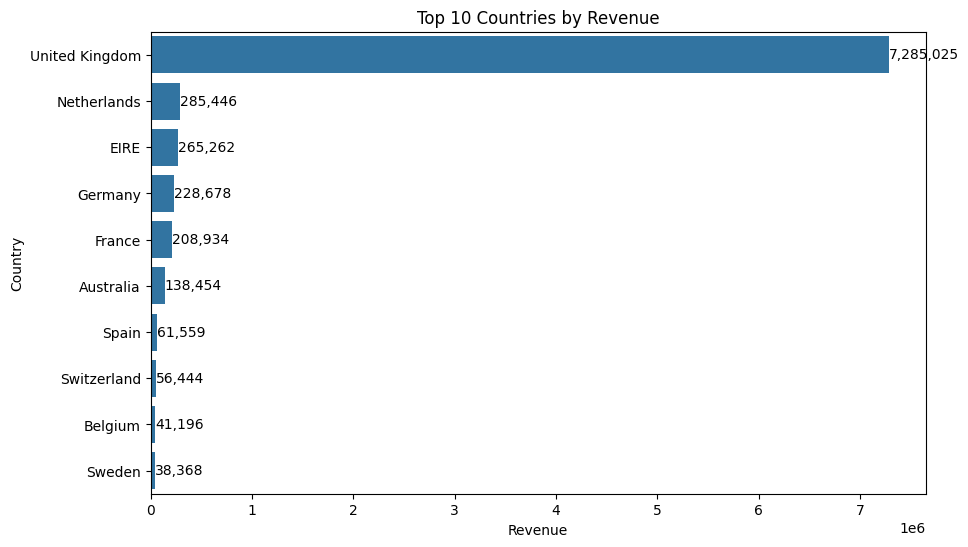

In [17]:
# Revenue by Country (Top 10)
# This groups total revenue by country to identify top-performing markets

country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=country_sales.values, y=country_sales.index)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

# Add values inside bars
for i, v in enumerate(country_sales.values):
    plt.text(v, i, f"{v:,.0f}", va="center", fontsize=10)

plt.show()

Insights:

The United Kingdom generates the highest revenue by a significant margin.

Revenue is highly concentrated in a few countries, indicating an uneven geographical distribution of sales.

Other countries contribute relatively smaller portions of total revenue, suggesting potential for market expansion outside the dominant region.

6.3 Monthly Revenue Trend

This analysis explores the monthly revenue pattern to understand how sales change over time. Revenue was aggregated by month to identify trends, fluctuations, and possible seasonality in customer purchasing behavior.

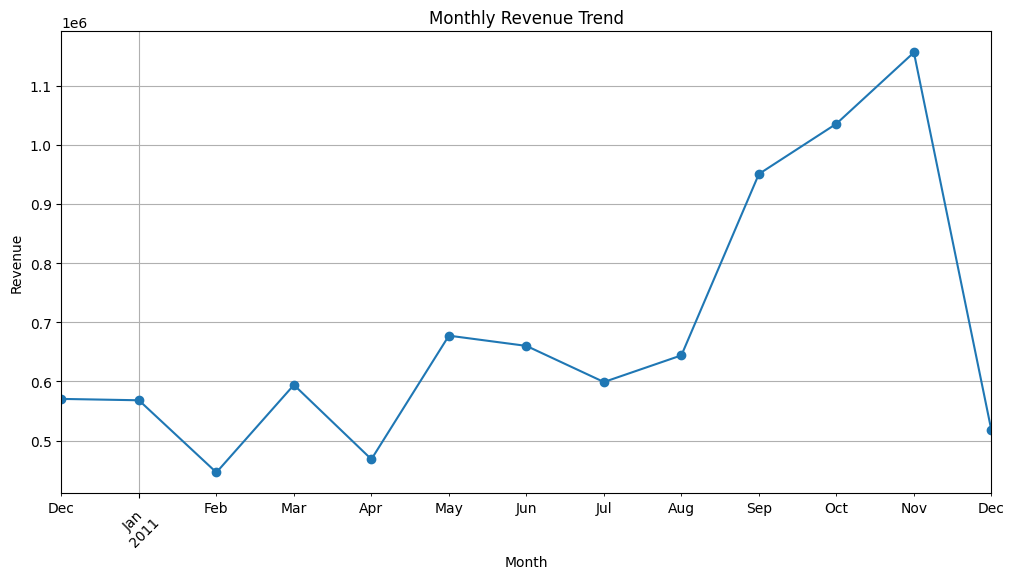

In [18]:
# Monthly Revenue Trend Analysis

monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12, 6))
monthly_sales.sort_index().plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()

plt.show()

Insight / Interpretation

Monthly sales show noticeable fluctuations over time.
This suggests the presence of seasonal buying patterns and variations in customer demand.

Certain months record higher revenue, indicating possible peak business periods, while others show lower sales activity.
These insights can help in demand forecasting, inventory planning, and seasonal marketing strategies.

6.4 Top Customers by Revenue

This analysis identifies the top 10 customers based on total revenue generated. The dataset was grouped by CustomerID, and the Revenue column was summed to determine each customer’s total contribution to sales.

This helps to understand customer value and identify high-value customers who contribute significantly to business revenue. Such insights are useful for customer segmentation, loyalty programs, and targeted marketing strategies.

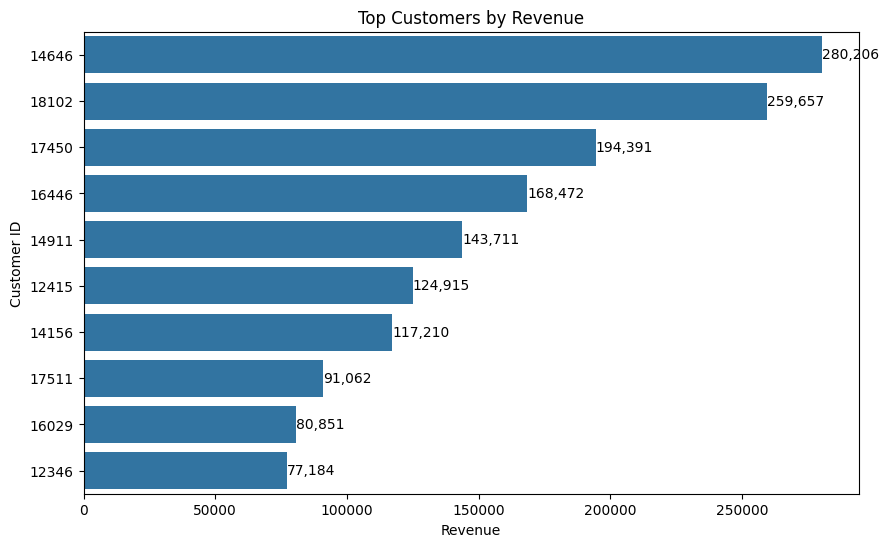

In [19]:
# Top Customers by Revenue

top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_customers.values, y=top_customers.index)

plt.title("Top Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

# Add values inside bars
for i, v in enumerate(top_customers.values):
    plt.text(v, i, f"{v:,.0f}", va="center", fontsize=10)

plt.show()

Insight Interpretation

The analysis shows that a small group of customers contributes a significant portion of the total revenue, highlighting the presence of high-value or “VIP” customers.

This suggests that the business may be relying heavily on a few key customers for sales performance. Focusing on customer retention strategies such as loyalty programs, personalized offers, and targeted engagement could help maintain and increase revenue from these top customers while also expanding the lower-tier customer base.

## 8. CONCLUSION

The exploratory data analysis of the Online Retail dataset provided meaningful insights into customer behavior, product performance, and revenue distribution patterns. Through data cleaning, transformation, and visualization, key trends such as high-value customers, dominant markets, and sales concentration were identified.

These insights can support data-driven decision-making in areas such as:

Inventory optimization and stock management
Customer segmentation and retention strategies
Sales forecasting and trend analysis
Targeted marketing and business strategy development

## 9. SAVE CLEANED DATASET

After completing data cleaning, transformation, feature engineering, and exploratory data analysis, the final cleaned dataset was saved for future use.


In [20]:
# Save cleaned dataset to a CSV file

df.to_csv("OnlineRetail_Cleaned.csv", index=False)